# Ticket: Feature Diagnostics - VIF & Multicollinearity Analysis
Dự án: Tốt nghiệp - Energy Forecasting - Nhóm thực hiện: The Outliers

## 1. TỔNG QUAN VÀ MỤC TIÊU
Notebook này thực hiện chẩn đoán đặc trưng (Feature Diagnostics) trên tập huấn luyện (`train_agg.parquet`) trước khi thực hiện bước lựa chọn đặc trưng chính thức ở Notebook 07:

1. **Phát hiện cột hằng số / gần hằng số**: Lọc các thuộc tính có phương sai bằng 0 hoặc chỉ có 1 giá trị duy nhất (`nunique <= 1`).
2. **Phân tích Missing Rate**: Báo cáo tỷ lệ khuyết dữ liệu trên các đặc trưng số.
3. **Phân tích Tương quan & Trùng lặp**: Xác định các cặp đặc trưng có hệ số tương quan tuyệt đối $|r| > 0.95$.
4. **Tính toán hệ số VIF (Variance Inflation Factor)**: Đo lường mức độ đa cộng tuyến của từng đặc trưng bằng mô hình hồi quy tuyến tính `sklearn.linear_model.LinearRegression` ($VIF_i = \frac{1}{1 - R^2_i}$).

> [!IMPORTANT]
> **LƯU Ý QUAN TRỌNG VỀ NGUYÊN TẮC CHẨN ĐOÁN:**
> Đây là bước **CHẨN ĐOÁN**, KHÔNG tự động xóa đặc trưng. Trong bài toán chuỗi thời gian (time-series), việc các đặc trưng Lag và Rolling có tương quan cao với nhau (`lag_1` và `rolling_mean_1h`) là **BÌNH THƯỜNG VÀ ĐÚNG THEO THIẾT KẾ** (vì cùng được sinh ra từ chuỗi sản lượng target). Không được tự ý loại bỏ Lag/Rolling chỉ vì chỉ số VIF cao. Quyết định loại bỏ hay giữ lại sẽ được xem xét toàn diện ở Notebook 07.

**Input:**
- `../../data/model/v4/03_3_features_aggregate/v4_train_features.parquet`

**Output:**
- `../../data/model/v4/04_diagnostics/feature_diagnostics.csv`

**Nguồn logic tham chiếu Audit:**
- Tham khảo ý tưởng từ `srcs/05_machine_learning/Forcasting_v3/06_vif_pls_diagnostics.py` (viết lại hoàn toàn bằng Pandas & Sklearn thuần).


## 2. Import thư viện và khai báo tham số
*Nguồn tham chiếu logic:* N/A (Setup chung)


In [1]:
# ── Gioi han thread: may i5-12450HX co 8 core / 12 thread (4 P-core + 4 E-core).
# Dung het 12 thread lam cac thread tranh nhau va CHAM HON. Dat 6 de bam P-core,
# con lai de cho Jupyter va he dieu hanh. Phai set TRUOC khi numpy nap moi co tac dung.
import os

for _bien in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS',
              'NUMEXPR_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS'):
    os.environ.setdefault(_bien, '6')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import gc
import pyarrow as pa
import pyarrow.parquet as pq
from sklearn.linear_model import LinearRegression

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# ── Tham số chẩn đoán ──
VIF_SAMPLE_SIZE = 50000        # Sample tính VIF
CORR_SAMPLE_SIZE = 200000      # Sample tính ma trận tương quan (đủ chính xác, nhẹ RAM)
CORR_HIGH_THRESHOLD = 0.95    # Ngưỡng tương quan cao (|r| > 0.95)
VIF_HIGH_THRESHOLD = 10.0      # Ngưỡng VIF đa cộng tuyến cao

# ── Đường dẫn (tương đối) ──
INPUT_PATH = "../../data/model/v4/03_3_features_aggregate/v4_train_features.parquet"
OUTPUT_PATH = "../../data/model/v4/04_diagnostics/feature_diagnostics.csv"

print("Đã import thư viện và khai báo tham số chẩn đoán.")
print(f"- Sample size cho VIF : {VIF_SAMPLE_SIZE}")
print(f"- Sample size cho corr: {CORR_SAMPLE_SIZE}")
print(f"- Ngưỡng tương quan trùng lặp: {CORR_HIGH_THRESHOLD}")
print(f"- Ngưỡng VIF cao: {VIF_HIGH_THRESHOLD}")
print(f"- Input: {INPUT_PATH}")
print(f"- Output: {OUTPUT_PATH}")


Đã import thư viện và khai báo tham số chẩn đoán.
- Sample size cho VIF : 50000
- Sample size cho corr: 200000
- Ngưỡng tương quan trùng lặp: 0.95
- Ngưỡng VIF cao: 10.0
- Input: ../../data/model/v4/03_3_features_aggregate/v4_train_features.parquet
- Output: ../../data/model/v4/04_diagnostics/feature_diagnostics.csv


## 3. Xác định danh sách đặc trưng số cần đọc

Đọc **schema** của file parquet trước, chưa nạp dữ liệu. Mục đích là chỉ nạp đúng các cột số cần chẩn đoán,
bỏ hẳn 19 cột chuỗi (`campus_name`, `weather_description`, `energy_source`, ...) vốn chiếm phần lớn RAM.


In [2]:
# Các cột loại trừ khỏi chẩn đoán (target, ID, provenance, outlier, thời gian thô)
EXCLUDE_EXACT = [
    'energy_generated_kwh',
    'gen_id', 'site_id', 'geo_id', 'date_id', 'time_id', 'weather_id', 'weather_type_id',
    'gmm_if_outlier_flag', 'gmm_if_outlier_reason', 'outlier_group',
    'exclude_from_training', 'exclude_reason', 'energy_source', 'timestamp_was_inserted',
    'timestamp', 'full_date'
]

schema = pq.ParquetFile(INPUT_PATH).schema_arrow
numeric_cols = [
    name for name, dtype in zip(schema.names, schema.types)
    if any(k in str(dtype) for k in ('double', 'float', 'int'))
    and name not in EXCLUDE_EXACT and not name.startswith('v4_')
]
skipped = [n for n in schema.names if n not in numeric_cols]

print(f"Tong so cot trong file : {len(schema.names)}")
print(f"So cot se nap          : {len(numeric_cols)}")
print(f"So cot bo qua          : {len(skipped)}")
print("\nDanh sach dac trung so dua vao chan doan:")
print(numeric_cols)


Tong so cot trong file : 114
So cot se nap          : 86
So cot bo qua          : 28

Danh sach dac trung so dua vao chan doan:
['year', 'month', 'day', 'day_of_week', 'hour', 'minute', 'capacity_kw', 'number_of_panels', 'latitude', 'longitude', 'shortwave_radiation', 'direct_normal_irradiance', 'diffuse_solar_radiation', 'temperature_c', 'cloud_cover_total', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high', 'wind_speed', 'sunshine_duration', 'source_gap_id', 'after_source_gap_steps_remaining', 'minute_of_day', 'quarter_hour', 'hour_of_day', 'day_of_week_model', 'month_model', 'day_of_year', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'is_weekend', 'season_code', 'hour_bucket_raw', 'hour_bucket_model', 'lag_4', 'lag_96', 'rolling_mean_4', 'rolling_std_4', 'rolling_min_4', 'rolling_max_4', 'rolling_mean_96', 'rolling_std_96', 'rolling_min_96', 'rolling_max_96', 'pv_clr_lonij', 'capacity_kw_missing_flag', 'number_of_panels_missing_flag', 'capacity_per_panel', 'solar_elevation',

## 4. Đọc dữ liệu (chỉ cột số, ép `float32`)

Chỉ nạp các cột đã chọn và ép về `float32`. So với đọc cả file, RAM giảm khoảng **8 lần**
(từ ~5,5 GB xuống ~0,7 GB), tránh tràn sang swap.


In [3]:
# Đọc theo từng row-group và ép float32 ngay trong Arrow trước khi sang pandas.
# Nếu đọc thẳng bằng pd.read_parquet rồi mới astype, có lúc tồn tại đồng thời
# bảng Arrow float64 + DataFrame float64 + DataFrame float32 -> đỉnh RAM cao hơn hẳn.
schema_f32 = pa.schema([pa.field(c, pa.float32()) for c in numeric_cols])
pf = pq.ParquetFile(INPUT_PATH)

parts = []
for i in range(pf.num_row_groups):
    tbl = pf.read_row_group(i, columns=numeric_cols).cast(schema_f32)
    parts.append(tbl.to_pandas())
    del tbl
    gc.collect()

df_train = pd.concat(parts, ignore_index=True)
del parts
gc.collect()

mem_mb = df_train.memory_usage(deep=True).sum() / 1024**2
print(f"Dang doc du lieu tu: {INPUT_PATH}")
print(f"So row-group da doc: {pf.num_row_groups}")
print(f"Tong so dong: {len(df_train)}")
print(f"Tong so cot : {len(df_train.columns)}")
print(f"RAM DataFrame chiem: {mem_mb:.0f} MB")
print("Sample Data:")
display(df_train.head(3))


Dang doc du lieu tu: ../../data/model/v4/03_3_features_aggregate/v4_train_features.parquet
So row-group da doc: 2
Tong so dong: 1550856
Tong so cot : 86
RAM DataFrame chiem: 509 MB
Sample Data:


,year,month,day,day_of_week,hour,minute,capacity_kw,number_of_panels,latitude,longitude,...,inverter_enc,inverter_unknown_flag,optimizers_enc,optimizers_unknown_flag,weather_join_method_enc,weather_join_method_unknown_flag,weather_condition_enc,weather_condition_unknown_flag,weather_description_enc,weather_description_unknown_flag
0,2020.0,1.0,1.0,2.0,0.0,15.0,51.150002,155.0,-36.11121,146.848679,...,18.0,0.0,23.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,2020.0,1.0,1.0,2.0,0.0,30.0,51.150002,155.0,-36.11121,146.848679,...,18.0,0.0,23.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,2020.0,1.0,1.0,2.0,0.0,45.0,51.150002,155.0,-36.11121,146.848679,...,18.0,0.0,23.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


## 5. Phát hiện cột hằng số và cột thiếu nhiều dữ liệu
Kiểm tra phương sai (`variance`), số giá trị duy nhất (`nunique`), và tỷ lệ khuyết (`nan_pct`).


In [4]:
stats_list = []
for col in numeric_cols:
    series = df_train[col]
    nan_pct = (series.isna().sum() / len(series)) * 100
    n_unique = series.nunique()
    var_val = series.var()
    
    flag = "OK"
    if n_unique <= 1 or var_val == 0:
        flag = "CONSTANT"
    elif nan_pct > 50.0:
        flag = "HIGH_MISSING"
        
    stats_list.append({
        'feature': col,
        'dtype': str(series.dtype),
        'nan_pct': round(nan_pct, 2),
        'nunique': n_unique,
        'variance': round(var_val, 6) if pd.notna(var_val) else np.nan,
        'flag_basic': flag
    })

df_basic_stats = pd.DataFrame(stats_list)
print("--- BÁO CÁO ĐẮC TRƯNG HẰNG SỐ & MISSING CAO ---")
display(df_basic_stats.sort_values('nan_pct', ascending=False))

--- BÁO CÁO ĐẮC TRƯNG HẰNG SỐ & MISSING CAO ---


,feature,dtype,nan_pct,nunique,variance,flag_basic
20,source_gap_id,float32,97.68,11,5.787878,HIGH_MISSING
67,dni_ratio,float32,47.43,37341,0.078009,OK
66,diffuse_ratio,float32,47.43,36672,0.078009,OK
46,pv_clr_lonij,float32,3.90,134433,108.175941,OK
58,rad_x_sinelev,float32,2.33,137733,42477.796875,OK
...,...,...,...,...,...,...
81,weather_join_method_unknown_flag,float32,0.00,1,0.000000,CONSTANT
82,weather_condition_enc,float32,0.00,8,4.550456,OK
83,weather_condition_unknown_flag,float32,0.00,1,0.000000,CONSTANT
84,weather_description_enc,float32,0.00,8,3.609966,OK


## 6. Ma trận tương quan và các cặp feature trùng lặp
Xác định các cặp đặc trưng số có $|r| > 0.95$.


In [5]:
# Tính ma trận tương quan Pearson trên sample.
# corr() trên toàn bộ 1,79 triệu dòng x 68 cột tốn ~1,5 GB và khoảng 4 tỷ phép tính.
# Sai số của hệ số tương quan trên 200.000 dòng dưới 0,3% - không đổi kết luận nào.
corr_sample = df_train.sample(n=min(CORR_SAMPLE_SIZE, len(df_train)), random_state=42)
corr_matrix = corr_sample.corr(method='pearson')
print(f"Tinh tuong quan tren sample {len(corr_sample)} / {len(df_train)} dong.")

# Tìm các cặp tương quan cao (|r| > 0.95)
high_corr_pairs = []
for i in range(len(numeric_cols)):
    for j in range(i + 1, len(numeric_cols)):
        f1, f2 = numeric_cols[i], numeric_cols[j]
        r_val = corr_matrix.loc[f1, f2]
        if abs(r_val) >= CORR_HIGH_THRESHOLD:
            high_corr_pairs.append({
                'feature_1': f1,
                'feature_2': f2,
                'correlation': round(r_val, 4)
            })

df_high_corr = pd.DataFrame(high_corr_pairs)
print(f"\n--- BÁO CÁO CÁC CẶP ĐẶC TRƯNG TƯƠNG QUAN CAO (|r| >= {CORR_HIGH_THRESHOLD}) ---")
print(f"Tổng số cặp tương quan cao: {len(df_high_corr)}")
display(df_high_corr)


Tinh tuong quan tren sample 200000 / 1550856 dong.

--- BÁO CÁO CÁC CẶP ĐẶC TRƯNG TƯƠNG QUAN CAO (|r| >= 0.95) ---
Tổng số cặp tương quan cao: 44


,feature_1,feature_2,correlation
0,month,month_model,1.0000
1,month,day_of_year,0.9965
2,day_of_week,day_of_week_model,1.0000
3,hour,minute_of_day,0.9992
4,hour,quarter_hour,0.9992
5,hour,hour_of_day,1.0000
6,hour,hour_bucket_raw,1.0000
7,hour,hour_bucket_model,1.0000
8,capacity_kw,number_of_panels,0.9885
9,shortwave_radiation,direct_normal_irradiance,0.9568


## 7. Loại bỏ đặc trưng trùng lặp (cộng tuyến hoàn hảo)

Trước khi tính VIF, gom các đặc trưng có `|r| >= 0.9999` vào cùng một nhóm và chỉ giữ một đại diện.
Trong nhóm cộng tuyến hoàn hảo, các cột mang **đúng cùng một thông tin**, nên giữ cột nào cũng như nhau — đại diện được chọn theo thứ tự xuất hiện.
Bỏ ở đây thay vì sửa ngược lên notebook 01/04 để việc loại bỏ có **bằng chứng số liệu kèm theo**, không phải bỏ tùy tiện.


In [6]:
# Nhóm các đặc trưng cộng tuyến HOÀN HẢO (|r| >= 0.9999) và chỉ giữ lại một đại diện.
# Ví dụ thực tế trong dữ liệu này:
#   - 10 cột *_missing giống hệt nhau vì metadata thiếu theo cả cụm (dòng nào thiếu thì thiếu hết)
#   - day_of_week trùng day_of_week_model, month trùng month_model (notebook 01 và 03 cùng sinh cột lịch)
#   - minute_of_day = quarter_hour * 15
DUP_THRESHOLD = 0.9999

duplicate_of = {}
keep_cols = []
for col in numeric_cols:
    rep = None
    for kept in keep_cols:
        r = corr_matrix.loc[col, kept]
        if pd.notna(r) and abs(r) >= DUP_THRESHOLD:
            rep = kept
            break
    if rep is None:
        keep_cols.append(col)
    else:
        duplicate_of[col] = rep

df_basic_stats['duplicate_of'] = df_basic_stats['feature'].map(duplicate_of)
df_basic_stats.loc[df_basic_stats['duplicate_of'].notna(), 'flag_basic'] = 'DUPLICATE'

print(f"--- BAO CAO DAC TRUNG TRUNG LAP (|r| >= {DUP_THRESHOLD}) ---")
print(f"Tong dac trung ban dau : {len(numeric_cols)}")
print(f"So dac trung trung lap : {len(duplicate_of)}")
print(f"So dac trung giu lai   : {len(keep_cols)}")

if duplicate_of:
    groups = {}
    for dup, rep in duplicate_of.items():
        groups.setdefault(rep, []).append(dup)
    print("\nCac nhom cong tuyen hoan hao (dai dien <- cac cot bi bo):")
    for rep, dups in groups.items():
        print(f"  {rep}")
        for d in dups:
            print(f"      bo: {d}")
    display(df_basic_stats[df_basic_stats['duplicate_of'].notna()][['feature', 'duplicate_of', 'nunique']])
else:
    print("Khong phat hien dac trung trung lap.")


--- BAO CAO DAC TRUNG TRUNG LAP (|r| >= 0.9999) ---
Tong dac trung ban dau : 86
So dac trung trung lap : 8
So dac trung giu lai   : 78

Cac nhom cong tuyen hoan hao (dai dien <- cac cot bi bo):
  minute_of_day
      bo: quarter_hour
  hour
      bo: hour_of_day
      bo: hour_bucket_raw
      bo: hour_bucket_model
  day_of_week
      bo: day_of_week_model
  month
      bo: month_model
  capacity_kw_missing_flag
      bo: number_of_panels_missing_flag
  diffuse_ratio
      bo: dni_ratio


,feature,duplicate_of,nunique
23,quarter_hour,minute_of_day,96
24,hour_of_day,hour,24
25,day_of_week_model,day_of_week,7
26,month_model,month,12
34,hour_bucket_raw,hour,24
35,hour_bucket_model,hour,24
48,number_of_panels_missing_flag,capacity_kw_missing_flag,2
67,dni_ratio,diffuse_ratio,37341


## 8. Tính VIF (Variance Inflation Factor)
Tính VIF cho từng đặc trưng bằng `sklearn.linear_model.LinearRegression`.

Công thức: $VIF_i = \frac{1}{1 - R^2_i}$

Lấy mẫu random `50,000` dòng từ `df_train` và điền tạm median cho các cột số để tính $R^2$ ổn định và nhanh chóng.


In [7]:
# Lấy sample để tính VIF nhanh và mượt
sample_df = df_train[keep_cols].sample(n=min(VIF_SAMPLE_SIZE, len(df_train)), random_state=42)

# Impute tạm thời bằng median chỉ để phục vụ tính VIF
sample_imputed = sample_df.fillna(sample_df.median())

# Loại bỏ các cột không có biến thiên (variance = 0) trong sample
valid_vif_cols = [c for c in keep_cols if sample_imputed[c].std() > 1e-6]

vif_results = {}
X_mat = sample_imputed[valid_vif_cols].values

print("Đang tính toán VIF bằng LinearRegression...")
for i, col in enumerate(valid_vif_cols):
    y = X_mat[:, i]
    X_other = np.delete(X_mat, i, axis=1)
    
    lr = LinearRegression()
    lr.fit(X_other, y)
    r2 = lr.score(X_other, y)
    
    if r2 >= 0.999999:
        vif_val = 9999.0  # Cap giá trị VIF cực lớn do phụ thuộc tuyến tính hoàn hảo
    else:
        vif_val = 1.0 / (1.0 - r2)
        
    vif_results[col] = round(vif_val, 2)

# Đưa kết quả VIF vào DataFrame cơ bản
df_basic_stats['vif'] = df_basic_stats['feature'].map(vif_results)

# Gán flag tổng hợp
flags = []
for idx, row in df_basic_stats.iterrows():
    if row['flag_basic'] != "OK":
        flags.append(row['flag_basic'])
    elif pd.notna(row['vif']) and row['vif'] > VIF_HIGH_THRESHOLD:
        flags.append("HIGH_VIF")
    else:
        flags.append("OK")

df_basic_stats['flag'] = flags
df_basic_stats = df_basic_stats.drop(columns=['flag_basic'])

print("\n--- BÁO CÁO KẾT QUẢ VIF TOP 15 CAO NHẤT ---")
display(df_basic_stats.sort_values('vif', ascending=False).head(15))


Đang tính toán VIF bằng LinearRegression...



--- BÁO CÁO KẾT QUẢ VIF TOP 15 CAO NHẤT ---


,feature,dtype,nan_pct,nunique,variance,duplicate_of,vif,flag
11,direct_normal_irradiance,float32,0.01,82956,40723.902344,NaN,9999.00,HIGH_VIF
12,diffuse_solar_radiation,float32,0.01,83681,7126.473633,NaN,9999.00,HIGH_VIF
10,shortwave_radiation,float32,0.01,84987,64634.890625,NaN,9999.00,HIGH_VIF
61,tran_cong_suat,float32,0.00,42,445.546173,NaN,7567.53,HIGH_VIF
60,site_scale,float32,0.00,42,427.562592,NaN,7516.67,HIGH_VIF
27,day_of_year,float32,0.00,366,10943.358398,NaN,5228.18,HIGH_VIF
1,month,float32,0.00,12,11.634602,NaN,5186.16,HIGH_VIF
54,sin_elevation,float32,2.32,84826,0.096201,NaN,2846.97,HIGH_VIF
41,rolling_max_4,float32,0.01,91698,86.833008,NaN,1375.52,HIGH_VIF
63,ty_le_bao_hoa,float32,2.32,639668,0.090233,NaN,1359.58,HIGH_VIF


## 9. Trực quan hóa (Heatmap tương quan + Bar Chart VIF)
Vẽ Heatmap tương quan Pearson giữa các đặc trưng số và Bar Chart thể hiện chỉ số VIF.


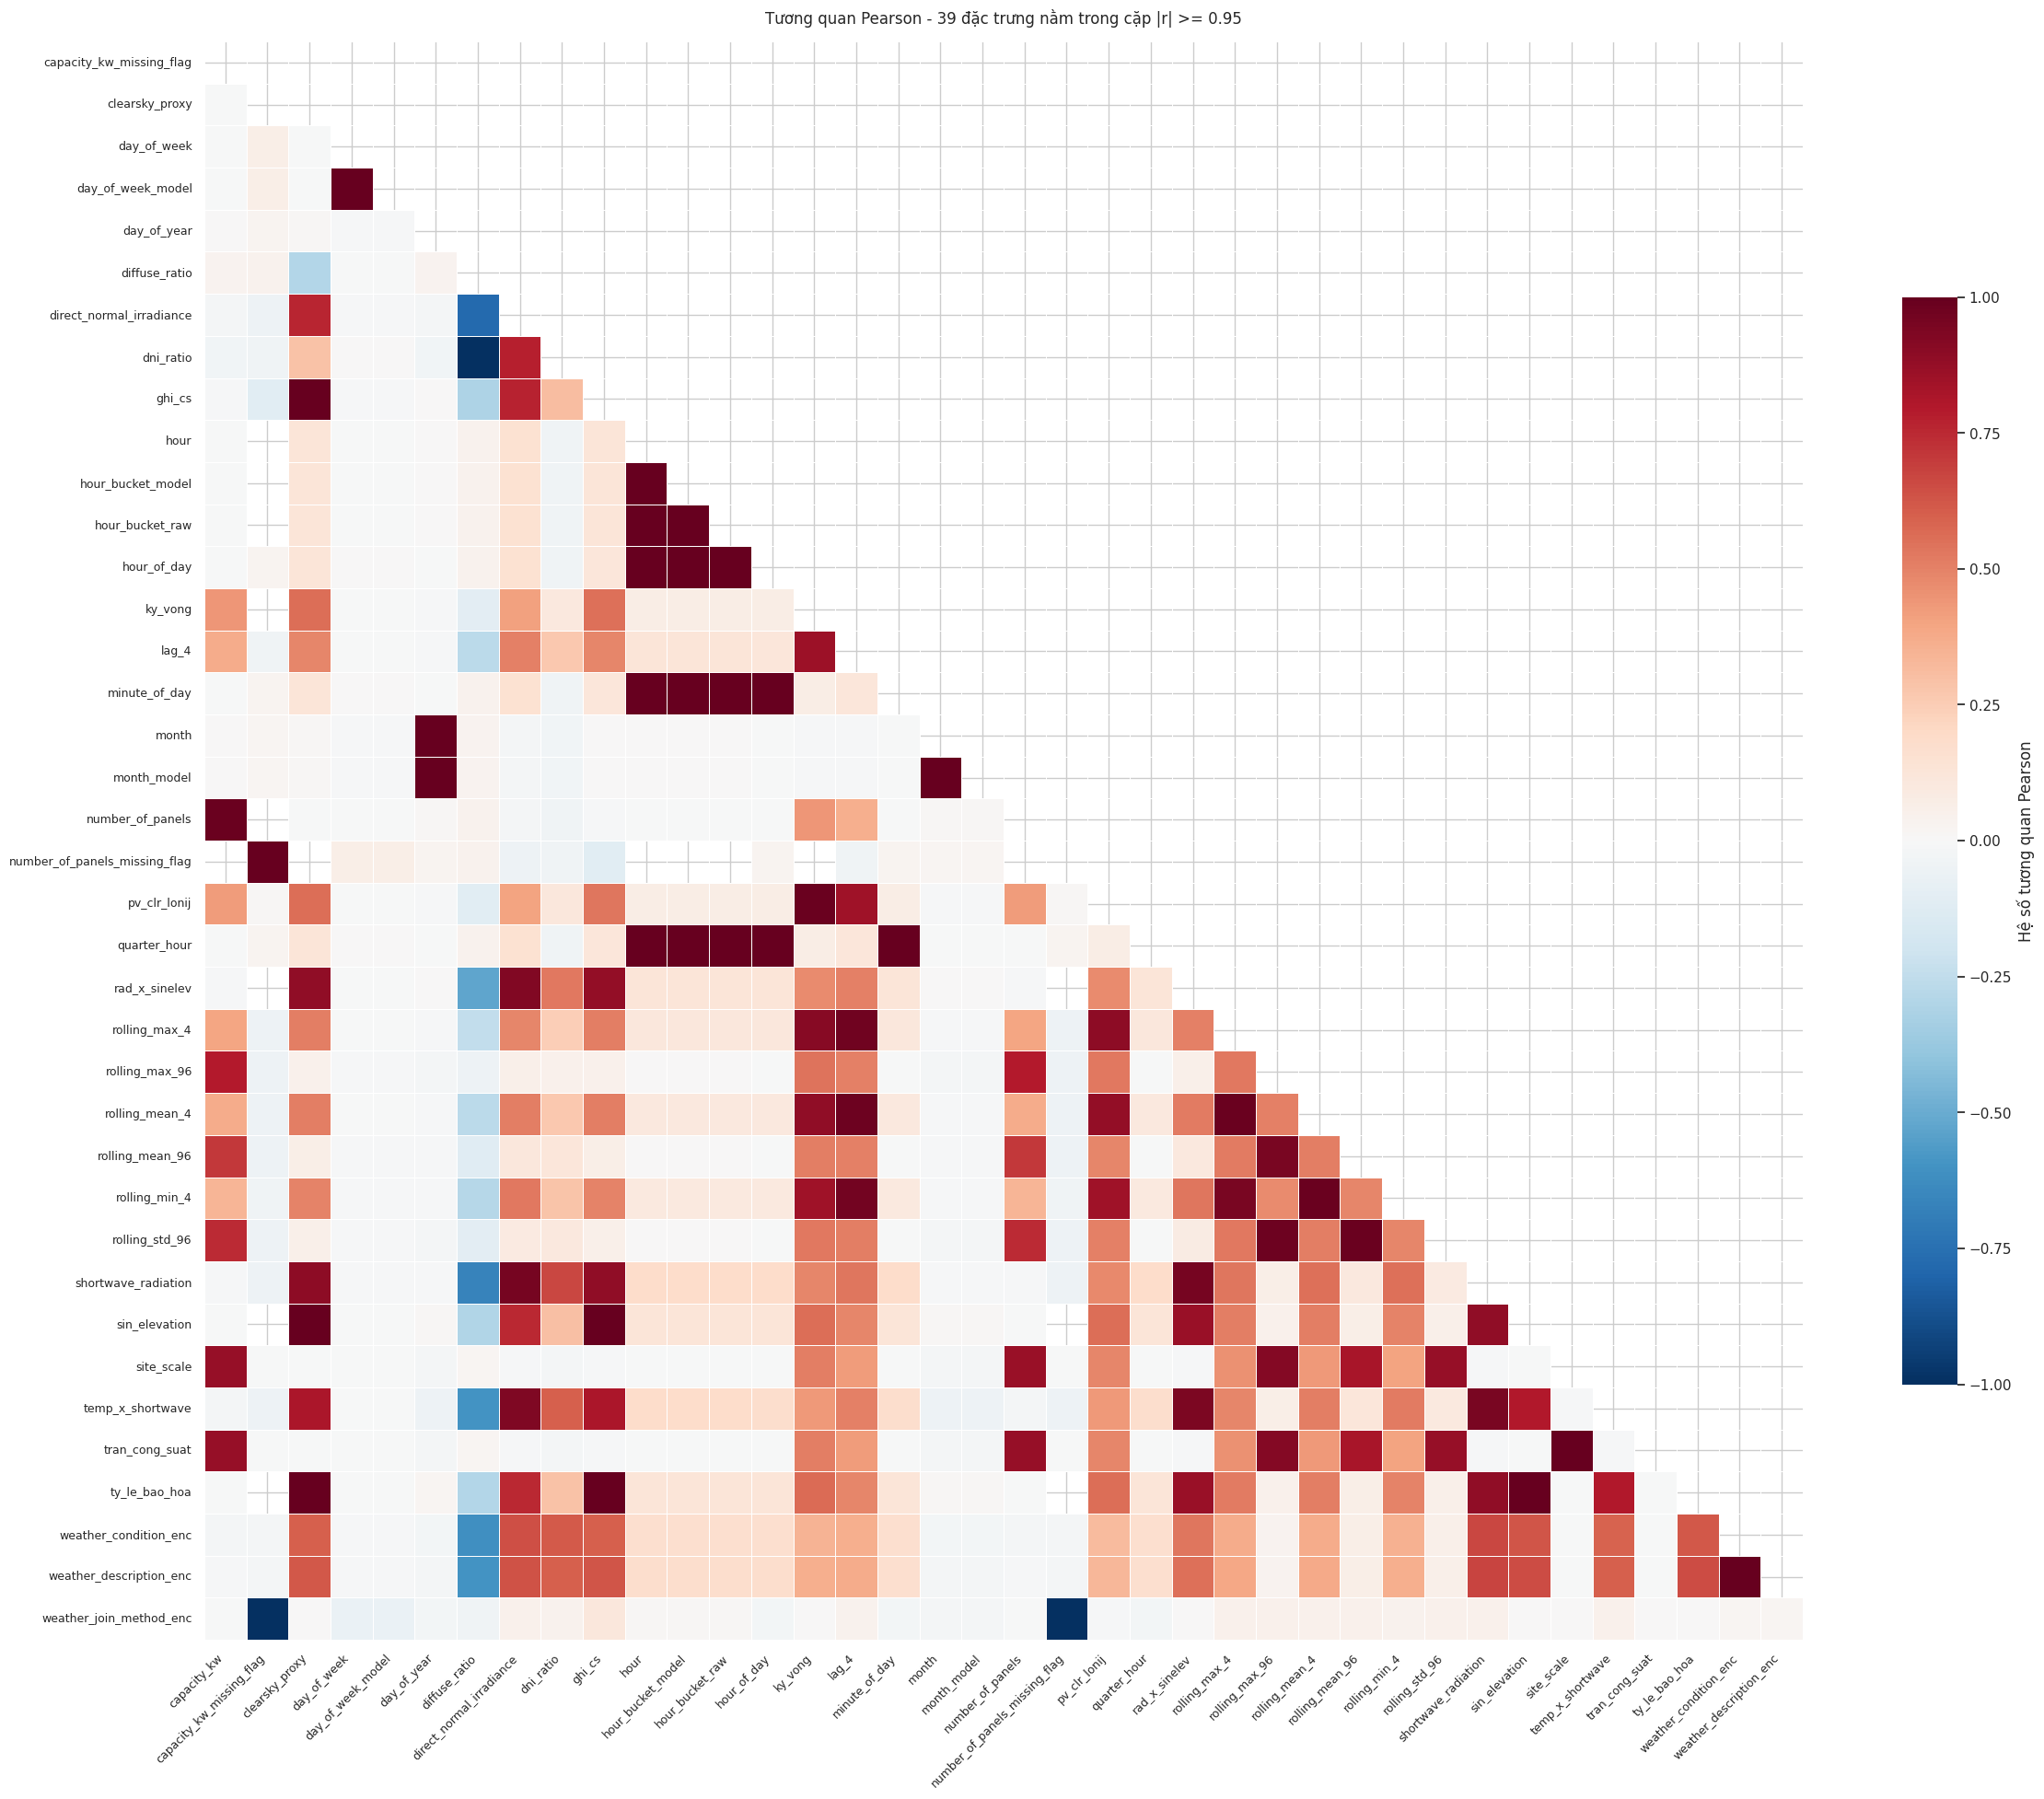

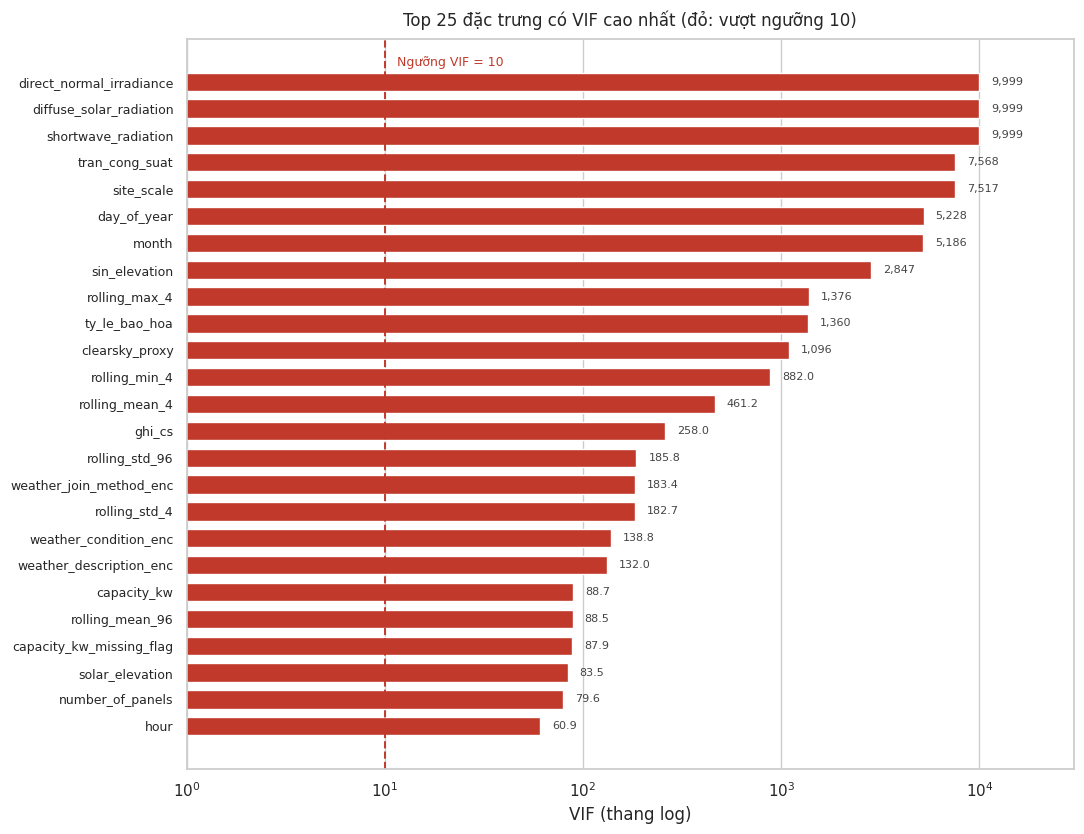

Heatmap hiển thị 39 / 86 đặc trưng (những đặc trưng nằm trong cặp tương quan cao).
Bar chart hiển thị Top 25 / 69 đặc trưng theo VIF.
Bảng đầy đủ của tất cả đặc trưng nằm trong file chẩn đoán xuất ở mục cuối.


In [8]:
# ── Biểu đồ 1: Heatmap tương quan ──
# 68 đặc trưng vẽ hết vào một hình thì nhãn chồng lên nhau không đọc được.
# Chỉ vẽ những đặc trưng thực sự nằm trong cặp tương quan cao đã tìm ở mục 6.
if len(df_high_corr):
    focus_cols = sorted(set(df_high_corr['feature_1']) | set(df_high_corr['feature_2']))
else:
    # Không có cặp nào vượt ngưỡng: lấy 20 đặc trưng tương quan mạnh nhất với phần còn lại
    strength = corr_matrix.abs().where(~np.eye(len(corr_matrix), dtype=bool)).max()
    focus_cols = strength.sort_values(ascending=False).head(20).index.tolist()

# Cắt hàng đầu và cột cuối: sau khi che nửa trên, hai dải đó không còn ô dữ liệu nào,
# chỉ còn nhãn lơ lửng. Mask k=1 để giữ lại đường chéo của phần còn lại.
sub_corr = corr_matrix.loc[focus_cols, focus_cols].iloc[1:, :-1]
mask_upper = np.triu(np.ones_like(sub_corr, dtype=bool), k=1)
n_focus = len(focus_cols)

fig, ax = plt.subplots(figsize=(max(9, n_focus * 0.62), max(7, n_focus * 0.54)))
sns.heatmap(
    sub_corr, mask=mask_upper, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    annot=(n_focus <= 20), fmt='.2f', annot_kws={'size': 8},
    linewidths=0.5, linecolor='white', square=True,
    cbar_kws={'shrink': 0.6, 'label': 'Hệ số tương quan Pearson'}, ax=ax,
)
ax.set_title(f"Tương quan Pearson - {n_focus} đặc trưng nằm trong cặp |r| >= {CORR_HIGH_THRESHOLD}",
             pad=14, fontsize=12)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

# ── Biểu đồ 2: Bar chart VIF ──
# Vẽ riêng một hình và chỉ lấy Top 25, vì 68 thanh trong một hình sẽ dính nhãn.
TOP_VIF = 25
vif_top = df_basic_stats.dropna(subset=['vif']).sort_values('vif', ascending=False).head(TOP_VIF)

fig, ax = plt.subplots(figsize=(11, max(5, len(vif_top) * 0.34)))
bar_colors = ['#c0392b' if v > VIF_HIGH_THRESHOLD else '#4878a8' for v in vif_top['vif']]
ax.barh(range(len(vif_top)), vif_top['vif'].values, color=bar_colors, height=0.68)
ax.set_yticks(range(len(vif_top)))
ax.set_yticklabels(vif_top['feature'], fontsize=9)
ax.invert_yaxis()

# Thang log vì VIF trải từ 1 tới hàng trăm nghìn; VIF = 1 nghĩa là không đa cộng tuyến
ax.set_xscale('log')
ax.set_xlim(1, max(vif_top['vif'].max() * 3, 100))
ax.axvline(VIF_HIGH_THRESHOLD, color='#c0392b', linestyle='--', linewidth=1.4)
ax.text(VIF_HIGH_THRESHOLD * 1.15, -0.7, f"Ngưỡng VIF = {VIF_HIGH_THRESHOLD:g}",
        color='#c0392b', fontsize=9, va='center')

for i, v in enumerate(vif_top['vif'].values):
    label = f"{v:,.0f}" if v >= 1000 else f"{v:,.1f}"
    ax.text(v * 1.15, i, label, va='center', fontsize=8, color='#444444')

ax.set_xlabel("VIF (thang log)")
ax.set_title(f"Top {len(vif_top)} đặc trưng có VIF cao nhất (đỏ: vượt ngưỡng {VIF_HIGH_THRESHOLD:g})",
             fontsize=12, pad=10)
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.show()

print(f"Heatmap hiển thị {n_focus} / {len(numeric_cols)} đặc trưng (những đặc trưng nằm trong cặp tương quan cao).")
print(f"Bar chart hiển thị Top {len(vif_top)} / {len(df_basic_stats.dropna(subset=['vif']))} đặc trưng theo VIF.")
print("Bảng đầy đủ của tất cả đặc trưng nằm trong file chẩn đoán xuất ở mục cuối.")


### Nhận xét và Đề xuất:
- **Các nhóm VIF cao (`vif > 10`)**: Thường tập trung ở các biến lag/rolling gần nhau (như `rolling_mean_1h` và `rolling_mean_3h`) hoặc các đặc trưng cyclical (`hour_sin/cos` kết hợp với `minute_of_day`).
- **Khuyến nghị cho bài toán Time-Series**: Không loại bỏ ngay lập tức các biến này vì đây là mối quan hệ vật lý theo chuỗi thời gian vốn có. Việc lựa chọn danh sách feature cuối cùng sẽ dựa trên Feature Importance từ mô hình Baseline ở Notebook 07.


## 9.5. Chẩn đoán Tầm quan trọng Đặc trưng bằng PLS (Partial Least Squares)
PLS giúp đánh giá nhanh sức mạnh dự đoán thực sự của từng đặc trưng (VIP - Variable Importance in Projection) đồng thời xử lý đa cộng tuyến.

In [9]:
from sklearn.cross_decomposition import PLSRegression
import numpy as np

print("Đang huấn luyện mô hình PLS Regression để tính VIP scores...")
n_comps = min(5, len(valid_vif_cols))
pls = PLSRegression(n_components=n_comps)

# X_mat đã được lấy sample và impute ở phần VIF
y_mat = pd.read_parquet(INPUT_PATH, columns=['energy_generated_kwh']).loc[sample_imputed.index, 'energy_generated_kwh'].values
pls.fit(X_mat, y_mat)

# --- Tính VIP (Variable Importance in Projection) ---
t = pls.x_scores_
w = pls.x_weights_
q = pls.y_loadings_
p, h = w.shape
vips = np.zeros((p,))
s = np.diag(t.T @ t @ q.T @ q).reshape(h, -1)
total_s = np.sum(s)

for i in range(p):
    weight = np.array([ (w[i,j] / np.linalg.norm(w[:,j]))**2 for j in range(h) ])
    vips[i] = np.sqrt(p * (s.T @ weight)/total_s)[0]

pls_results = {col: round(float(vips[i]), 3) for i, col in enumerate(valid_vif_cols)}

# Gắn kết quả PLS VIP vào bảng report
df_basic_stats['pls_vip'] = df_basic_stats['feature'].map(pls_results)

print("\n--- TOP 15 ĐẶC TRƯNG QUAN TRỌNG NHẤT THEO PLS VIP ---")
print("(Ngưỡng VIP > 1.0 thường được coi là đặc trưng cực kỳ quan trọng)")
display(df_basic_stats.sort_values('pls_vip', ascending=False).head(15))


Đang huấn luyện mô hình PLS Regression để tính VIP scores...



--- TOP 15 ĐẶC TRƯNG QUAN TRỌNG NHẤT THEO PLS VIP ---
(Ngưỡng VIP > 1.0 thường được coi là đặc trưng cực kỳ quan trọng)


,feature,dtype,nan_pct,nunique,variance,duplicate_of,vif,flag,pls_vip
38,rolling_mean_4,float32,0.01,207779,65.935349,NaN,461.18,HIGH_VIF,2.265
40,rolling_min_4,float32,0.01,83278,50.097061,NaN,882.04,HIGH_VIF,2.251
41,rolling_max_4,float32,0.01,91698,86.833008,NaN,1375.52,HIGH_VIF,2.224
36,lag_4,float32,0.01,104326,67.909042,NaN,27.77,HIGH_VIF,2.123
62,ky_vong,float32,2.32,643996,95.668503,NaN,21.18,HIGH_VIF,2.039
46,pv_clr_lonij,float32,3.90,134433,108.175941,NaN,10.80,HIGH_VIF,1.959
37,lag_96,float32,0.26,104320,67.963173,NaN,5.36,OK,1.883
39,rolling_std_4,float32,0.01,540345,2.304145,NaN,182.73,HIGH_VIF,1.532
10,shortwave_radiation,float32,0.01,84987,64634.890625,NaN,9999.00,HIGH_VIF,1.282
63,ty_le_bao_hoa,float32,2.32,639668,0.090233,NaN,1359.58,HIGH_VIF,1.276


## 10. Export bảng chẩn đoán
Xuất bảng kết quả chẩn đoán chi tiết ra file CSV.


In [10]:
import os

out_dir = os.path.dirname(OUTPUT_PATH)
os.makedirs(out_dir, exist_ok=True)

df_basic_stats.to_csv(OUTPUT_PATH, index=False)

print(f"Đã xuất bảng kết quả chẩn đoán ra: {OUTPUT_PATH}")
print(f"Tổng số đặc trưng đã chẩn đoán: {len(df_basic_stats)}")
print("Phân bố các nhãn chẩn đoán (flag):")
print(df_basic_stats['flag'].value_counts())
display(df_basic_stats.head(10))

Đã xuất bảng kết quả chẩn đoán ra: ../../data/model/v4/04_diagnostics/feature_diagnostics.csv
Tổng số đặc trưng đã chẩn đoán: 86
Phân bố các nhãn chẩn đoán (flag):
flag
HIGH_VIF        41
OK              27
CONSTANT         9
DUPLICATE        8
HIGH_MISSING     1
Name: count, dtype: int64


,feature,dtype,nan_pct,nunique,variance,duplicate_of,vif,flag,pls_vip
0,year,float32,2.32,2,0.246623,NaN,2.70,OK,0.083
1,month,float32,0.00,12,11.634602,NaN,5186.16,HIGH_VIF,0.058
2,day,float32,2.32,31,75.371452,NaN,28.44,HIGH_VIF,0.022
3,day_of_week,float32,0.00,7,4.004874,NaN,2.55,OK,0.017
4,hour,float32,2.32,24,47.925152,NaN,60.88,HIGH_VIF,0.381
5,minute,float32,2.32,4,281.206207,NaN,1.10,OK,0.017
6,capacity_kw,float32,2.32,25,10243.511719,NaN,88.73,HIGH_VIF,1.054
7,number_of_panels,float32,2.32,25,61905.363281,NaN,79.56,HIGH_VIF,1.044
8,latitude,float32,2.32,5,0.666758,NaN,4.49,OK,0.139
9,longitude,float32,2.32,5,0.787840,NaN,1.75,OK,0.040
